
**Testing the Unet with good images and excessprint defect images**

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
import os
os.chdir('/content/gdrive/My Drive/')
os.getcwd()

'/content/gdrive/My Drive'

In [ ]:
import tensorflow as tf
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Model
import cv2
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate, Conv2DTranspose, BatchNormalization, Dropout, Lambda
from keras.utils import to_categorical

Reading the file path of training images

In [ ]:
path = '/content/gdrive/My Drive/project/temp/train_images/'
files = sorted(os.listdir(path))
print(files)

['1 (1).bmp', '1 (10).bmp', '1 (11).bmp', '1 (12).bmp', '1 (13).bmp', '1 (15).bmp', '1 (2).bmp', '1 (3).bmp', '1 (5).bmp', '1 (6).bmp', '1 (7).bmp', '1 (8).bmp', '184 (1).bmp', '184 (10).bmp', '184 (11).bmp', '184 (12).bmp', '184 (14).bmp', '184 (15).bmp', '184 (16).bmp', '184 (17).bmp', '184 (19).bmp', '184 (2).bmp', '184 (20).bmp', '184 (21).bmp', '184 (22).bmp', '184 (24).bmp', '184 (25).bmp', '184 (26).bmp', '184 (4).bmp', '184 (5).bmp', '184 (6).bmp', '184 (7).bmp', '184 (9).bmp', '25 (1).bmp', '25 (10).bmp', '25 (11).bmp', '25 (3).bmp', '25 (4).bmp', '25 (5).bmp', '25 (6).bmp', '25 (8).bmp', '25 (9).bmp', '277 (1).bmp', '277 (10).bmp', '277 (11).bmp', '277 (13).bmp', '277 (14).bmp', '277 (15).bmp', '277 (16).bmp', '277 (18).bmp', '277 (19).bmp', '277 (20).bmp', '277 (21).bmp', '277 (23).bmp', '277 (24).bmp', '277 (25).bmp', '277 (3).bmp', '277 (4).bmp', '277 (5).bmp', '277 (6).bmp', '277 (8).bmp', '277 (9).bmp', '3 (1).bmp', '3 (10).bmp', '3 (11).bmp', '3 (12).bmp', '3 (2).bmp', 

In [ ]:
train_images = []   

for each_image in files:
  if each_image.endswith(".bmp"):
      
      full_path =path + each_image
      #print (full_path)
      image = cv2.imread(full_path)
      #print (image)
      image = cv2.resize(image,(256,256),interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

      train_images.append(image)

#print(train_images.shape)
train_images = np.asarray(train_images)
print(train_images.shape)
print(train_images[2])

(960, 256, 256)
[[219 219 217 ... 222 225 227]
 [214 218 217 ... 224 226 220]
 [217 223 225 ... 224 226 221]
 ...
 [223 221 216 ... 220 225 225]
 [217 223 216 ... 219 226 225]
 [220 222 219 ... 220 223 220]]


Reading the file path of training labels

In [ ]:
path1 = '/content/gdrive/My Drive/project/temp/train_labels/'
files1 = sorted(os.listdir(path1))
print(files1)

['1 (1).bmp', '1 (10).bmp', '1 (11).bmp', '1 (12).bmp', '1 (13).bmp', '1 (15).bmp', '1 (2).bmp', '1 (3).bmp', '1 (5).bmp', '1 (6).bmp', '1 (7).bmp', '1 (8).bmp', '184 (1).bmp', '184 (10).bmp', '184 (11).bmp', '184 (12).bmp', '184 (14).bmp', '184 (15).bmp', '184 (16).bmp', '184 (17).bmp', '184 (19).bmp', '184 (2).bmp', '184 (20).bmp', '184 (21).bmp', '184 (22).bmp', '184 (24).bmp', '184 (25).bmp', '184 (26).bmp', '184 (4).bmp', '184 (5).bmp', '184 (6).bmp', '184 (7).bmp', '184 (9).bmp', '25 (1).bmp', '25 (10).bmp', '25 (11).bmp', '25 (3).bmp', '25 (4).bmp', '25 (5).bmp', '25 (6).bmp', '25 (8).bmp', '25 (9).bmp', '277 (1).bmp', '277 (10).bmp', '277 (11).bmp', '277 (13).bmp', '277 (14).bmp', '277 (15).bmp', '277 (16).bmp', '277 (18).bmp', '277 (19).bmp', '277 (20).bmp', '277 (21).bmp', '277 (23).bmp', '277 (24).bmp', '277 (25).bmp', '277 (3).bmp', '277 (4).bmp', '277 (5).bmp', '277 (6).bmp', '277 (8).bmp', '277 (9).bmp', '3 (1).bmp', '3 (10).bmp', '3 (11).bmp', '3 (12).bmp', '3 (2).bmp', 

In [ ]:
train_labels = []

for each_image in files1:
  if each_image.endswith(".bmp"):
      
      full_path1 =path1 + each_image
      #print (full_path)
      image = cv2.imread(full_path1)
      #print (image)
      image = cv2.resize(image,(256,256),interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

      train_labels.append(image)

#print(train_images.shape)
train_labels = np.asarray(train_labels)
print(train_labels.shape)

(960, 256, 256)


In [ ]:
print(np.unique(train_labels))

[0 1 2]


Reading the file path of test images

In [ ]:
path2 = '/content/gdrive/My Drive/project/temp/test_images/'
files2 = sorted(os.listdir(path2))
print(files2)

['1 (14).bmp', '1 (4).bmp', '1 (9).bmp', '184 (13).bmp', '184 (18).bmp', '184 (23).bmp', '184 (3).bmp', '184 (8).bmp', '25 (12).bmp', '25 (2).bmp', '25 (7).bmp', '277 (12).bmp', '277 (17).bmp', '277 (2).bmp', '277 (22).bmp', '277 (7).bmp', '3 (4).bmp', '3 (9).bmp', '307 (12).bmp', '307 (17).bmp', '307 (2).bmp', '307 (22).bmp', '307 (27).bmp', '307 (7).bmp', '39 (10).bmp', '39 (5).bmp', '739 (10).bmp', '739 (15).bmp', '739 (20).bmp', '739 (5).bmp', '811 (1).bmp', '811 (11).bmp', '811 (16).bmp', '811 (21).bmp', '811 (26).bmp', '811 (6).bmp', '996 (13).bmp', '996 (18).bmp', '996 (3).bmp', '996 (8).bmp', 'Img_ (10).bmp', 'Img_ (100).bmp', 'Img_ (1000).bmp', 'Img_ (105).bmp', 'Img_ (110).bmp', 'Img_ (115).bmp', 'Img_ (120).bmp', 'Img_ (125).bmp', 'Img_ (130).bmp', 'Img_ (135).bmp', 'Img_ (140).bmp', 'Img_ (145).bmp', 'Img_ (15).bmp', 'Img_ (150).bmp', 'Img_ (155).bmp', 'Img_ (160).bmp', 'Img_ (165).bmp', 'Img_ (170).bmp', 'Img_ (175).bmp', 'Img_ (180).bmp', 'Img_ (185).bmp', 'Img_ (190).bmp

In [ ]:
test_images = []

for each_image in files2:
  if each_image.endswith(".bmp"):
      
      full_path2 =path2 + each_image
      #print (full_path)
      image = cv2.imread(full_path2)
      #print (image)
      image = cv2.resize(image,(256,256),interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

      test_images.append(image)

#print(train_images.shape)
test_images = np.asarray(test_images)
print(test_images.shape)

(240, 256, 256)


Reading the file path of test labels

In [ ]:
path3 = '/content/gdrive/My Drive/project/temp/test_labels/'
files3 = sorted(os.listdir(path3))
print(files3)

['1 (14).bmp', '1 (4).bmp', '1 (9).bmp', '184 (13).bmp', '184 (18).bmp', '184 (23).bmp', '184 (3).bmp', '184 (8).bmp', '25 (12).bmp', '25 (2).bmp', '25 (7).bmp', '277 (12).bmp', '277 (17).bmp', '277 (2).bmp', '277 (22).bmp', '277 (7).bmp', '3 (4).bmp', '3 (9).bmp', '307 (12).bmp', '307 (17).bmp', '307 (2).bmp', '307 (22).bmp', '307 (27).bmp', '307 (7).bmp', '39 (10).bmp', '39 (5).bmp', '739 (10).bmp', '739 (15).bmp', '739 (20).bmp', '739 (5).bmp', '811 (1).bmp', '811 (11).bmp', '811 (16).bmp', '811 (21).bmp', '811 (26).bmp', '811 (6).bmp', '996 (13).bmp', '996 (18).bmp', '996 (3).bmp', '996 (8).bmp', 'Img_ (10).bmp', 'Img_ (100).bmp', 'Img_ (1000).bmp', 'Img_ (105).bmp', 'Img_ (110).bmp', 'Img_ (115).bmp', 'Img_ (120).bmp', 'Img_ (125).bmp', 'Img_ (130).bmp', 'Img_ (135).bmp', 'Img_ (140).bmp', 'Img_ (145).bmp', 'Img_ (15).bmp', 'Img_ (150).bmp', 'Img_ (155).bmp', 'Img_ (160).bmp', 'Img_ (165).bmp', 'Img_ (170).bmp', 'Img_ (175).bmp', 'Img_ (180).bmp', 'Img_ (185).bmp', 'Img_ (190).bmp

In [ ]:
test_labels = []

for each_image in files3:
  if each_image.endswith(".bmp"):
      
      full_path3 =path3 + each_image
      #print (full_path)
      image = cv2.imread(full_path3)
      #print (image)
      image = cv2.resize(image,(256,256),interpolation=cv2.INTER_AREA)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
      image = cv2.cvtColor(image,cv2.COLOR_BGR2GRAY)

      test_labels.append(image)

#print(train_images.shape)
test_labels = np.asarray(test_labels)
print(test_labels.shape)

(240, 256, 256)


[[1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 ...
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]
 [1 1 1 ... 1 1 1]]
[0 1 2]


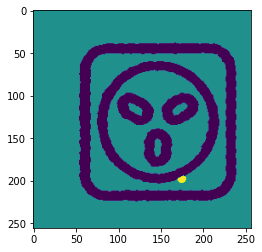

In [ ]:
img = test_labels[2]
plt.imshow(img)
print(img)
print(np.unique(test_labels))

Normalization

In [ ]:
x_train = train_images.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), 256,256,1))
x_test = test_images.astype('float32') / 255.
x_test = x_test.reshape((len(x_test), 256,256,1))
                  

In [ ]:
y_train = train_labels.astype('float32') #/ 255.
y_train = y_train.reshape((len(y_train), 256,256,1))
y_test = test_labels.astype('float32') #/ 255.
y_test = y_test.reshape((len(y_test), 256,256,1))
                  

In [ ]:
print(y_train.shape)

(960, 256, 256, 1)


In [ ]:
img_width = 256
img_height = 256
img_channels = 1
n_classes=3

converting the each output pixel into 3clases for segmentation 

In [ ]:
y_train_cat = to_categorical(y_train,num_classes=n_classes)
print(y_train_cat.shape)

(960, 256, 256, 3)


In [ ]:
print(y_test.shape)

(240, 256, 256, 1)


In [ ]:
y_test_cat = to_categorical(y_test,num_classes=n_classes)

In [ ]:
print(y_test_cat.shape)

(240, 256, 256, 3)


In [ ]:
print(np.unique(y_train))

[0. 1. 2.]


 Building the multiclass UNet model

In [ ]:

def segmentation_model(n_classes=3, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=1):
#Build the model
    s = Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    #s = Lambda(lambda x: x / 255)(inputs)   #No need for this if we normalize our inputs beforehand
    input= s

    #Contraction path
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(input)
    c1 = Dropout(0.1)(c1)
    c1 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
    c2 = Dropout(0.1)(c2)
    c2 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
     
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
    c3 = Dropout(0.2)(c3)
    c3 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
     
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
    c4 = Dropout(0.2)(c4)
    c4 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
    p4 = MaxPooling2D(pool_size=(2, 2))(c4)
     
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
    c5 = Dropout(0.3)(c5)
    c5 = Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)
    
    #Expansive path 
    u6 = Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
    u6 = concatenate([u6, c4])
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
    c6 = Dropout(0.2)(c6)
    c6 = Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)
     
    u7 = Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
    u7 = concatenate([u7, c3])
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
    c7 = Dropout(0.2)(c7)
    c7 = Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)
     
    u8 = Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
    u8 = concatenate([u8, c2])
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
    c8 = Dropout(0.1)(c8)
    c8 = Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)
     
    u9 = Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
    u9 = concatenate([u9, c1], axis=3)
    c9 = Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
    c9 = Dropout(0.1)(c9)
    c9 = Conv2D(16, (1, 1), activation='relu', kernel_initializer='he_normal', padding='same')(c9)
     
    outputs = Conv2D(n_classes, (1, 1), activation='softmax')(c9)
     
    segmentation_model = Model(inputs=[s], outputs=[outputs])
    
    return segmentation_model


Model compilation

In [ ]:
# for 2 class segmentation, loss is binary_crossentropy
model = segmentation_model(n_classes=3, IMG_HEIGHT=256, IMG_WIDTH=256, IMG_CHANNELS=1)
optimizer = tf.keras.optimizers.Adam(0.001)
model.compile(optimizer= optimizer,loss='categorical_crossentropy',metrics=['accuracy']) 
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 256, 256, 1  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 256, 256, 16  160         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 dropout (Dropout)              (None, 256, 256, 16  0           ['conv2d[0][0]']                 
                                )                                                             

In [ ]:
from keras.utils.vis_utils import plot_model

In [ ]:
#Model checkpoint
checkpoint = tf.keras.callbacks.ModelCheckpoint('model_for_printedimages',verbose = 1, save_best_only=True)
callbacks = [tf.keras.callbacks.EarlyStopping(patience=2,monitor='val_loss')]

Training the model

In [ ]:
hist=model.fit(x_train, y_train_cat,
                epochs=60,
                batch_size=16,
                shuffle=True,
                #class_weights=class_weights,
                validation_data=(x_test, y_test_cat) )

Epoch 1/60
60/60 [==============================] - 33s 215ms/step - loss: 0.3101 - accuracy: 0.8552 - val_loss: 0.0548 - val_accuracy: 0.9808
Epoch 2/60
60/60 [==============================] - 12s 204ms/step - loss: 0.0367 - accuracy: 0.9876 - val_loss: 0.0249 - val_accuracy: 0.9908
Epoch 3/60
60/60 [==============================] - 12s 193ms/step - loss: 0.0270 - accuracy: 0.9905 - val_loss: 0.0199 - val_accuracy: 0.9927
Epoch 4/60
60/60 [==============================] - 11s 192ms/step - loss: 0.0235 - accuracy: 0.9916 - val_loss: 0.0175 - val_accuracy: 0.9936
Epoch 5/60
60/60 [==============================] - 11s 189ms/step - loss: 0.0205 - accuracy: 0.9925 - val_loss: 0.0147 - val_accuracy: 0.9947
Epoch 6/60
60/60 [==============================] - 11s 188ms/step - loss: 0.0182 - accuracy: 0.9932 - val_loss: 0.0133 - val_accuracy: 0.9950
Epoch 7/60
60/60 [==============================] - 11s 188ms/step - loss: 0.0166 - accuracy: 0.9935 - val_loss: 0.0119 - val_accuracy: 0.9953

plotting of training and validation loss wrt epochs

In [ ]:
model.save('unet_excessprint.hdf5')  # saving the model

In [ ]:
model.save_weights('unet_excessprint_weights.h5') # saving the model weights

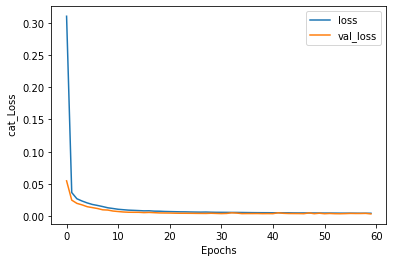

In [ ]:
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.xlabel('Epochs')
plt.ylabel(' cat_Loss')
plt.legend(['loss', 'val_loss'])
plt.show()

evaluation of model

In [ ]:
# acc = hist.history['accuracy']
# val_acc = hist.history['val_accuracy']

In [ ]:
_, acc = model.evaluate(x_test, y_test_cat)
print("Accuracy is = ", (acc * 100.0), "%")

8/8 [==============================] - 3s 80ms/step - loss: 0.0035 - accuracy: 0.9986
Accuracy is =  99.85790848731995 %


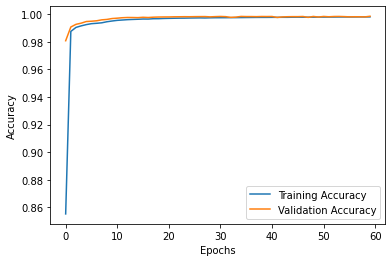

In [ ]:
plt.plot(hist.history['accuracy'])
plt.plot(hist.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

In [ ]:
#IOU
y_pred=model.predict(x_test)
y_pred_argmax=np.argmax(y_pred, axis=3)

8/8 [==============================] - 1s 75ms/step


In [ ]:
#Using built in keras function
from keras.metrics import MeanIoU
n_classes = 3
IOU_keras = MeanIoU(num_classes=n_classes)  
IOU_keras.update_state(y_test[:,:,:,0], y_pred_argmax)
print("Mean IoU =", IOU_keras.result().numpy())

Mean IoU = 0.96075696


In [ ]:
model.load_weights('unet_excessprint_weights.h5')

In [ ]:
#To calculate I0U for each class...
values = np.array(IOU_keras.get_weights()).reshape(n_classes, n_classes)
print(values)
class1_IoU = values[0,0]/(values[0,0] + values[0,1] + values[0,2] + values[1,0]+ values[2,0])
class2_IoU = values[1,1]/(values[1,1] + values[1,0] + values[1,2] + values[0,1]+ values[2,1])
class3_IoU = values[2,2]/(values[2,2] + values[2,0] + values[2,1] + values[0,2]+ values[1,2])


[[3.7745810e+06 5.0110000e+03 8.5300000e+02]
 [1.5833000e+04 1.1919554e+07 2.7500000e+02]
 [2.5700000e+02 1.2000000e+02 1.2156000e+04]]


In [ ]:
print("IoU for class1 is: ", class1_IoU)
print("IoU for class2 is: ", class2_IoU)
print("IoU for class3 is: ", class3_IoU)

IoU for class1 is:  0.99421734
IoU for class2 is:  0.9982213
IoU for class3 is:  0.8898324


Plotting the segmented image by network

In [ ]:
import random
test_img_number = random.randint(0, len(x_test))
test_img = x_test[test_img_number]
ground_truth=y_test[test_img_number]
test_img_norm=test_img[:,:,0][:,:,None]
test_img_input=np.expand_dims(test_img_norm, 0)
prediction = (model.predict(test_img_input))
predicted_img=np.argmax(prediction, axis=3)[0,:,:]

1/1 [==============================] - 0s 17ms/step


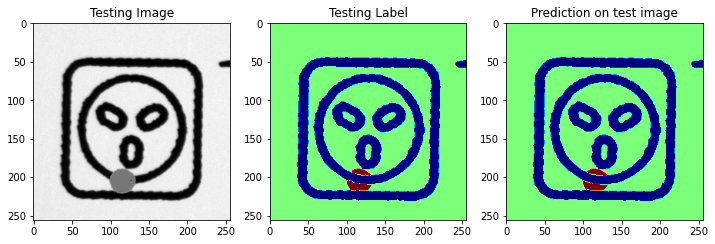

In [ ]:
plt.figure(figsize=(12, 8))
plt.subplot(231)
plt.title('Testing Image')
plt.imshow(test_img[:,:,0], cmap='gray')
plt.subplot(232)
plt.title('Testing Label')
plt.imshow(ground_truth[:,:,0], cmap='jet')
plt.subplot(233)
plt.title('Prediction on test image')
plt.imshow(predicted_img, cmap='jet')
plt.show()